In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import os

sys.path.insert(0, '../scripts/')

from importlib import reload

import small_utilities
reload(small_utilities)
import Block_analysis
reload(Block_analysis)

from Block_analysis import *
from small_utilities import *

import seaborn as sns
from collections import OrderedDict


## Analysis for $\alpha$-synuclien with Fasudil (Trajectory-1)

In this notebook we will analize the Meta dynamics trajectories of $\alpha$-synuclien in presence of Fasudil.

### Loading the data

The colvar files are generated from the concatinated trajectories at the respective time intervels. For example, $100ns$ for each replica trajectory is obtained and concatinated togeather, which is used to compute the weights. 

In [2]:
# work_directory = os.getcwd()
work_directory = '/data/ssREST3/Fasudil/PBMetaD-1/'
a = np.sort([i for i in os.listdir(work_directory) if os.path.isdir(f'{work_directory}/{i}')])

print(f'Current working dir: \n{work_directory}\n')
print(f'which has the following directories: \n{a}')
print(os.getcwd())

Current working dir: 
/data/ssREST3/Fasudil/PBMetaD-1/

which has the following directories: 
['colvar' 'data']
/data/ssREST3/Fasudil


In [3]:
colvar_data={}
weights_norm={}

last_time=2000

for i in range(0,2000, 100):

    if i==0:
        colvar_data[i+last_time]=np.loadtxt(f'{work_directory}/{a[0]}/colvar_{i}.dat', comments=['#','@'])
        num_cvs, _, weights_norm[i+last_time] = norm_weights(f'{work_directory}/{a[0]}/colvar_{i}.dat')
        print(f"Sum of combined xtc weights : {np.sum(weights_norm[i+last_time])}")
        print(f"Number of frames : {colvar_data[i+last_time].shape[0]}")
    else:
            
        colvar_data[i]=np.loadtxt(f'{work_directory}/{a[0]}/colvar_{i}.dat', comments=['#','@'])
        num_cvs, _, weights_norm[i] = norm_weights(f'{work_directory}/{a[0]}/colvar_{i}.dat')

        print(f"Sum of combined xtc weights : {np.sum(weights_norm[i])}")
        print(f"Number of frames : {colvar_data[i].shape[0]}")
    


Sum of combined xtc weights : 0.999999999999999
Number of frames : 3200001
Sum of combined xtc weights : 0.9999999999999998
Number of frames : 160001
Sum of combined xtc weights : 0.9999999999999999
Number of frames : 320001
Sum of combined xtc weights : 1.0
Number of frames : 480001
Sum of combined xtc weights : 0.9999999999999999
Number of frames : 640001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 800001
Sum of combined xtc weights : 0.9999999999999993
Number of frames : 960001
Sum of combined xtc weights : 1.0
Number of frames : 1120001
Sum of combined xtc weights : 0.9999999999999998
Number of frames : 1280001
Sum of combined xtc weights : 1.0000000000000004
Number of frames : 1440001
Sum of combined xtc weights : 1.0
Number of frames : 1600001
Sum of combined xtc weights : 1.0
Number of frames : 1760001
Sum of combined xtc weights : 1.0000000000000007
Number of frames : 1920001
Sum of combined xtc weights : 1.0000000000000002
Number of frames : 2080001
Sum

### Plot for 100ns data (3200ns(3.2 $\mu$ s) aggregate time.)

By changing the `index` we will plot the CV's of respective aggregate time.

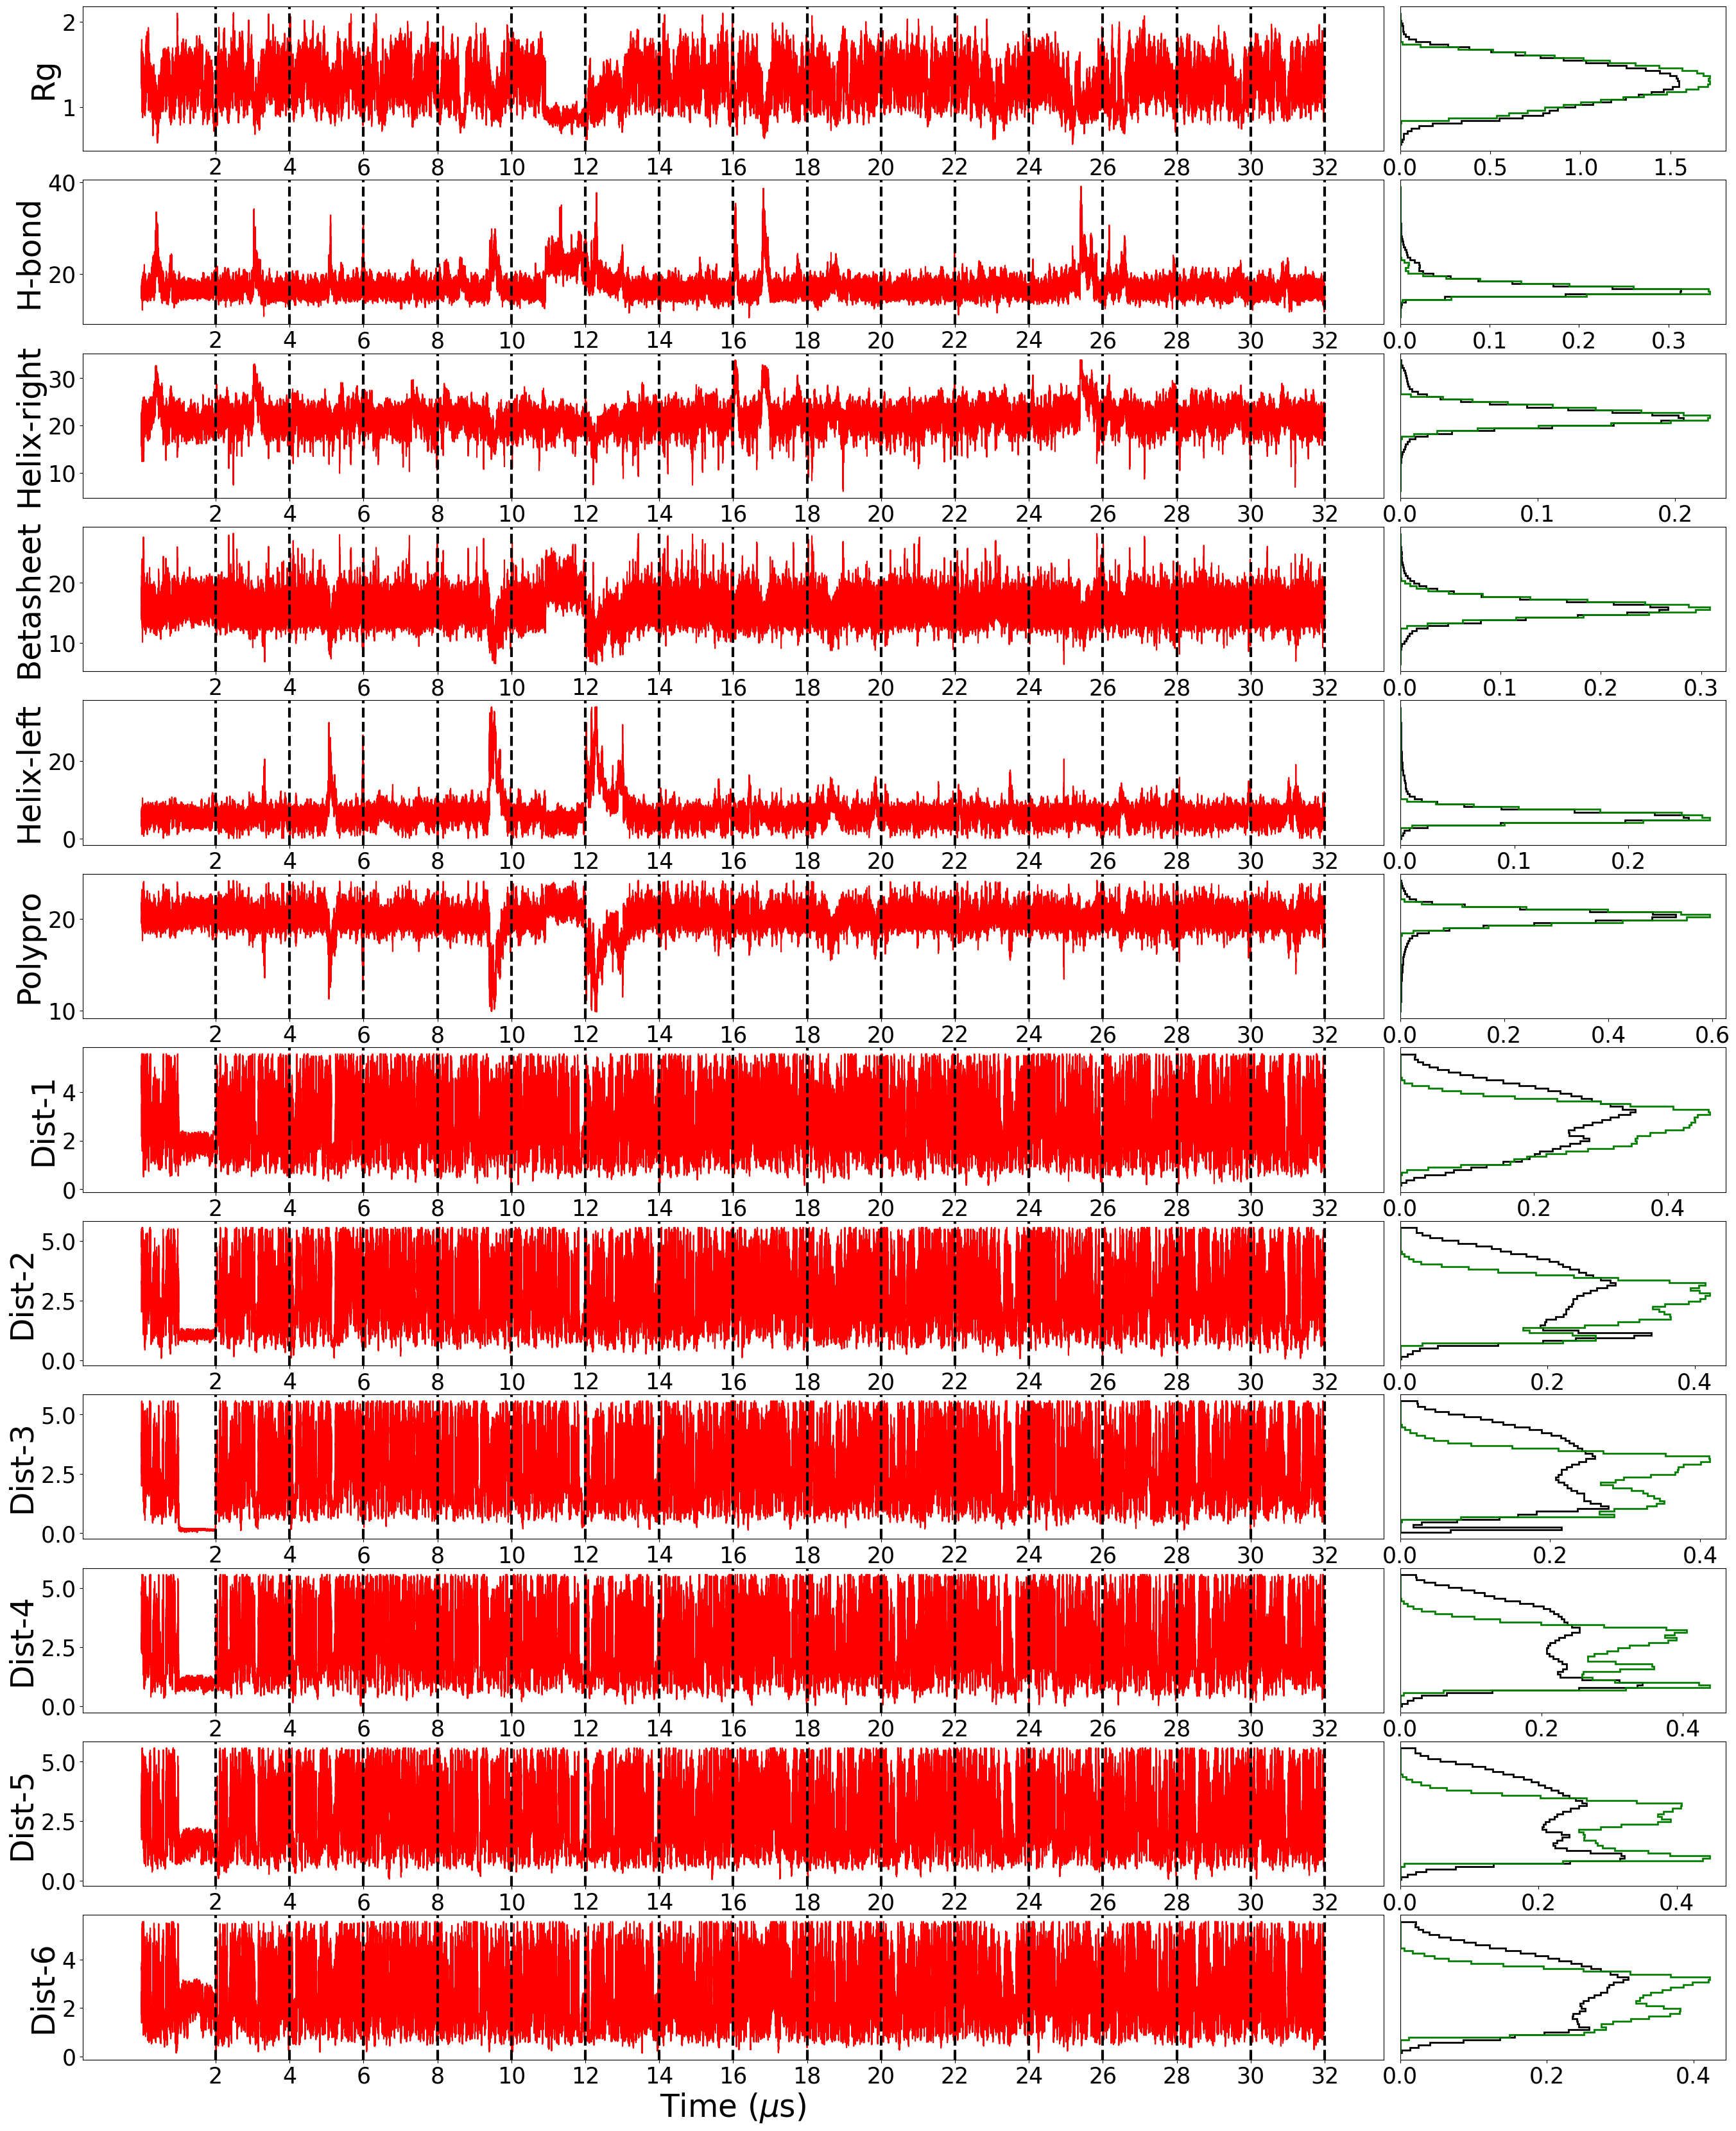

In [9]:
label={
    '1':'Rg', '2':'H-bond', '3':'Helix-right', '4':'Betasheet', '5':'Helix-left', '6':'Polypro',
    '7':'Dist-1', '8':'Dist-2', '9':'Dist-3', '10':'Dist-4', '11':'Dist-5', '12':'Dist-6'
       }

# change the value of index from 100 to 1000 to see the plot for the different aggregate data
index=2000
trj_frames=create_trj_frames(colvar_data[index])

plot_colvar(colvar_data[index], trj_frames, num_cvs, labels=label, weights=weights_norm[index])

### Free energy plot of Rg computed plotted from the respective colver files

In [13]:
index_dict={
    'Rg':1, 'H-bond':2, 'Helix-right':3, 'Betasheet':4, 'Helix-left':5, 'Polypro':6,
    'Dist-1':7, 'Dist-2':8, 'Dist-3':9, 'Dist-4':10, 'Dist-5':11, 'Dist-6':12
       }

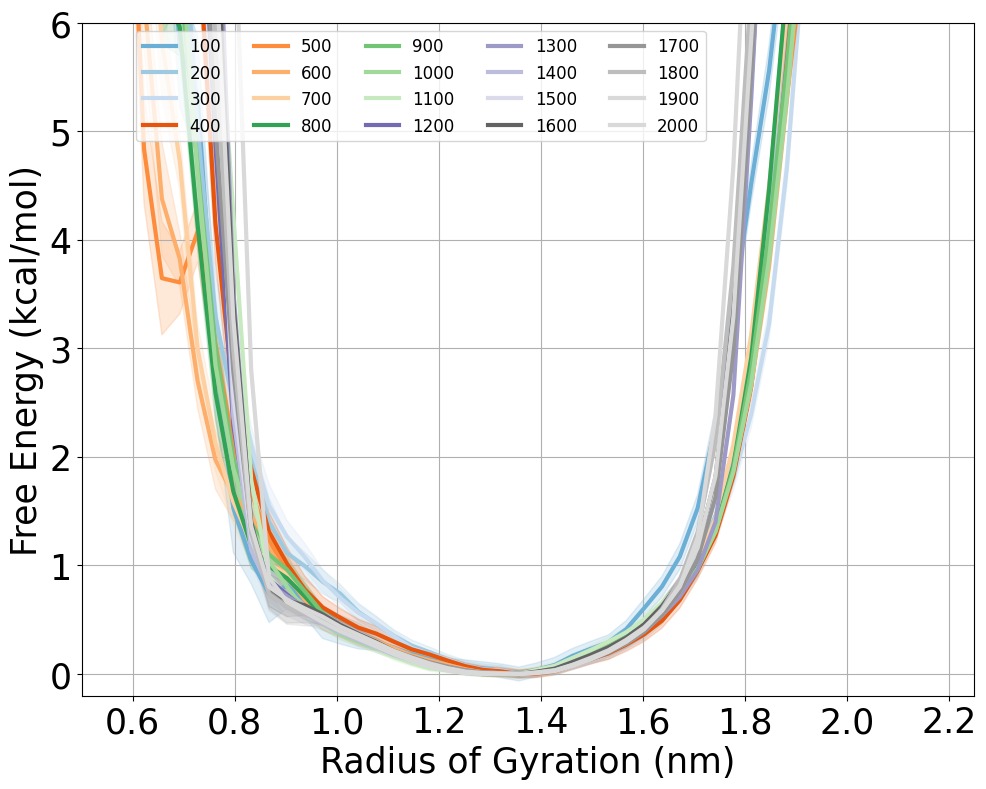

In [105]:
np.seterr(invalid='ignore')

plt.figure(figsize=(10,8))

for i in range(100,2100, 100):
    dG1, bin_centers, ferr = free_energy_1D_blockerror(colvar_data[i].T[index_dict['Rg']], T=300, x0=0.5, xmax=2.25, bins=50, blocks_no=None, weights=weights_norm[i])

    sns.lineplot(x=bin_centers, y=dG1, color=plt.cm.tab20c(int(i/100)), linewidth=3,label=str(i), linestyle='-')
    plt.fill_between(bin_centers, dG1-ferr, dG1+ferr, color=plt.cm.tab20c(int(i/100)), alpha=0.2)

plt.ylim(-0.2, 6)
plt.xlim(0.5, 2.25)
plt.xlabel('Radius of Gyration (nm)', size=25)
plt.ylabel('Free Energy (kcal/mol)', size=25)
plt.legend(loc='upper center', fontsize=12, ncol=5, bbox_to_anchor=(0.38, 1.0))
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.title(f"Replica : {val}", size=20)
plt.tight_layout()
plt.grid()
plt.show()

In [23]:
mean_rg=np.zeros((20,2))
# mean_rg_err=np.zeros(10)

for i in range(100,2100, 100):
    # print(f'{i} : {get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[1], weights_norm[i])}')
    mean_rg[int(i/100)-1]=get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[index_dict['Rg']], weights_norm[i])

mean_rg

array([[1.2747962 , 0.03032597],
       [1.33180877, 0.01547839],
       [1.33402035, 0.01312823],
       [1.32356838, 0.01753654],
       [1.30346639, 0.01331816],
       [1.30250254, 0.0138523 ],
       [1.2959406 , 0.01128472],
       [1.29694805, 0.01179085],
       [1.30189638, 0.01018558],
       [1.29434735, 0.01046727],
       [1.28566171, 0.01024935],
       [1.29104492, 0.01203281],
       [1.30046501, 0.01072693],
       [1.2880074 , 0.01088758],
       [1.29567916, 0.01058404],
       [1.29139898, 0.01167224],
       [1.29590636, 0.01177674],
       [1.28834062, 0.01260183],
       [1.29513818, 0.01206114],
       [1.29172224, 0.00907028]])

### $<Rg>$ plotted against aggregate time

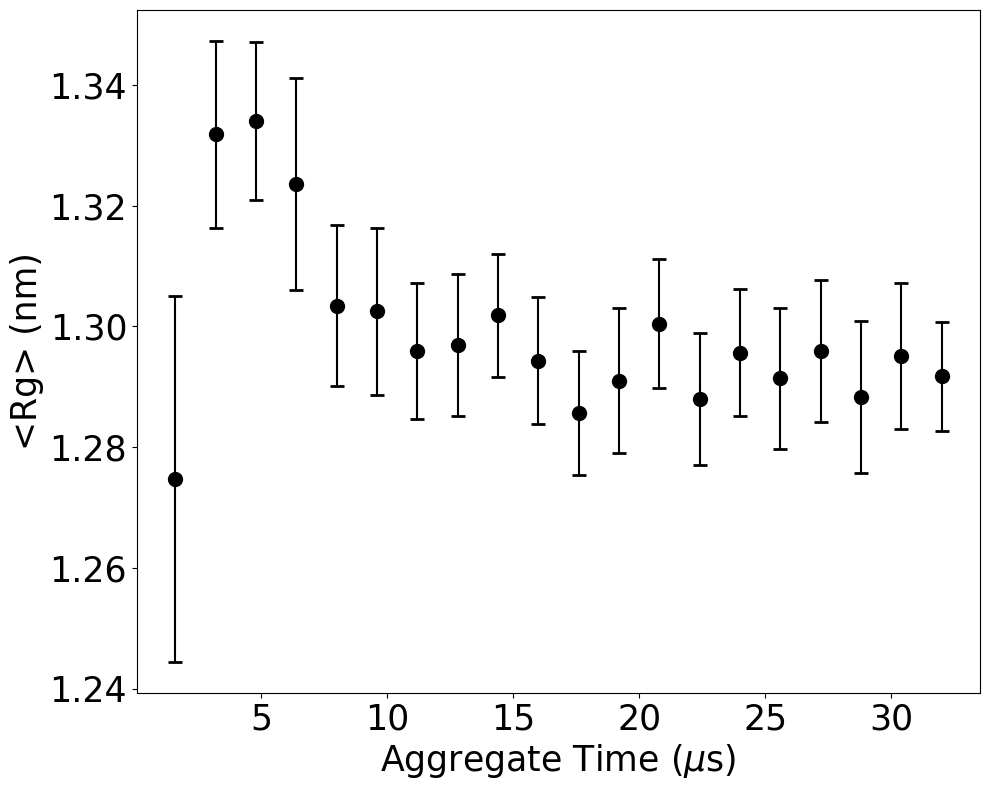

In [25]:
plt.figure(figsize=(10,8))

plt.errorbar(np.arange(0.1,2.1,0.1)*16, mean_rg.T[0], yerr=mean_rg.T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)

plt.tick_params(labelsize=25)
plt.xlabel(r'Aggregate Time ($\mu$s)', size=25)
plt.ylabel(r'<Rg> (nm)', size=25)
plt.tight_layout()

### Loading Bound fraction data

In [4]:
file_name='bound_fraction.json'

bf_fas=[]

for i in range(0, 2000, 100):

    bf_fas.append(load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}'))

bf_fas = np.array([bf_fas[i]['0'] for i in range(len(bf_fas))])
bf_fas = reposition_first(bf_fas)

### Plot of bound fraction w.r.t aggregate simulation time

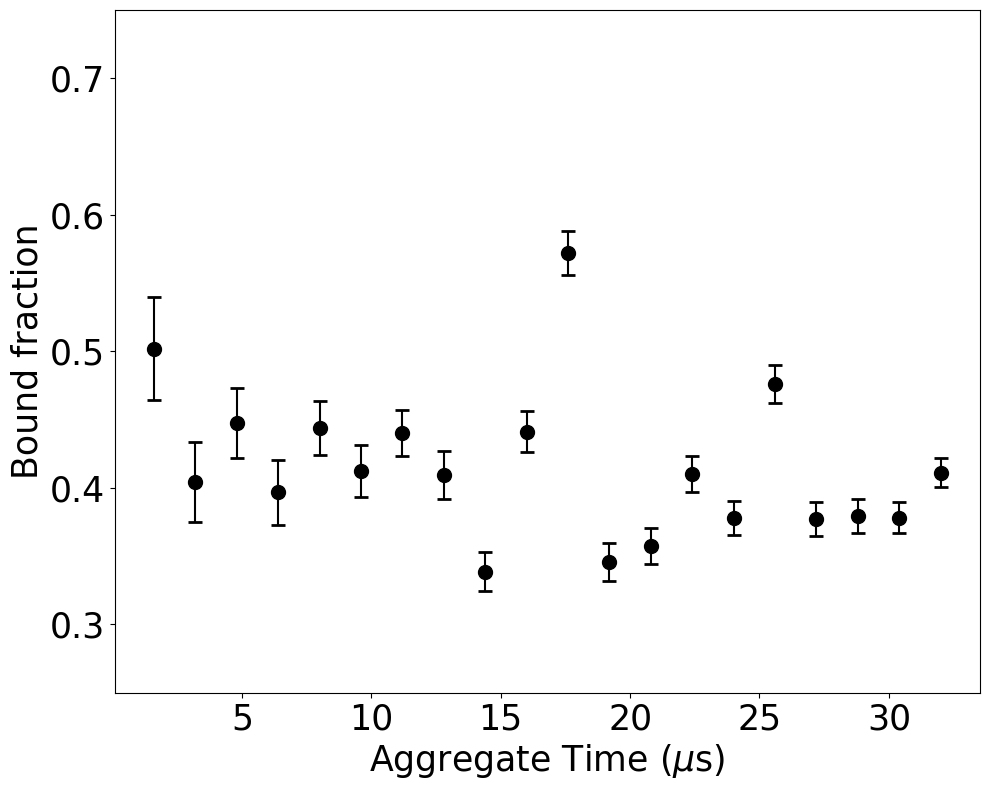

In [10]:
plt.figure(figsize=(10,8))

plt.errorbar(np.arange(0.1,2.1,0.1)*16, bf_fas.T[0], yerr=bf_fas.T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)

plt.tick_params(labelsize=25)
plt.xlabel(r'Aggregate Time ($\mu$s)', size=25)
plt.ylabel(r'Bound fraction', size=25)
plt.ylim(0.25,0.75)
plt.tight_layout()


### Free energy for 6 distances computed between protein and small molecule

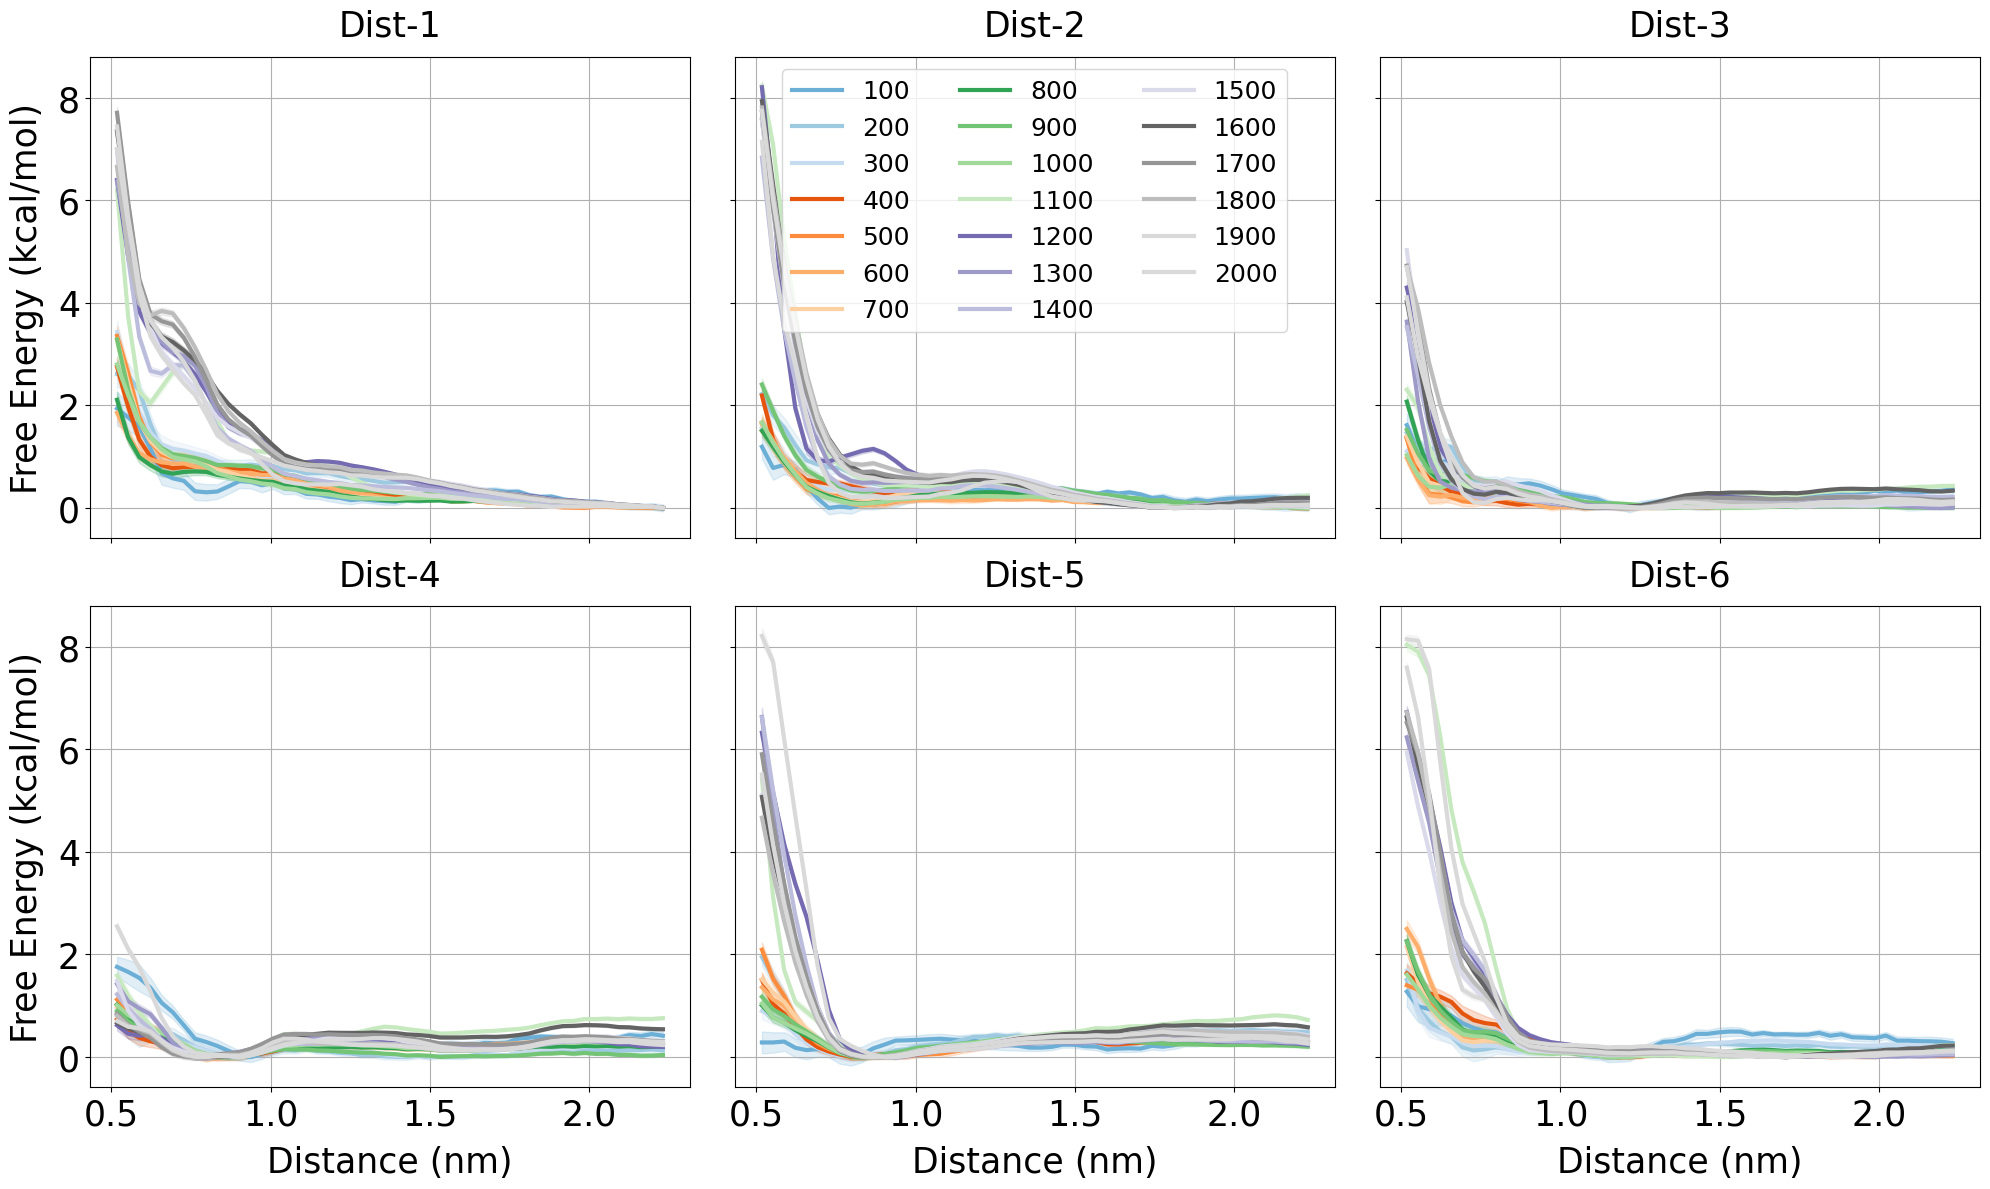

In [106]:
np.seterr(invalid='ignore')

fig, ax = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)

for d in range(0,6):

    p,q = np.unravel_index(d,(2,3))

    for i in range(100,2100, 100):
        dG1, bin_centers, ferr = free_energy_1D_blockerror(colvar_data[i].T[d+7], T=300, x0=0.5, xmax=2.25, bins=50, blocks_no=None, weights=weights_norm[i])

        sns.lineplot(x=bin_centers, y=dG1, color=plt.cm.tab20c(int(i/100)), linewidth=3,label=str(i), linestyle='-', ax=ax[p,q])
        ax[p,q].fill_between(bin_centers, dG1-ferr, dG1+ferr, color=plt.cm.tab20c(int(i/100)), alpha=0.2)

    ax[p,q].tick_params(labelsize=25)
    # ax[p,q].set_ylim(-0.2, 2)
    # ax[p,q].set_xlim(0.5, 2.25)
    ax[p,q].set_xlabel(f'Distance (nm)', size=25, labelpad=10)
    ax[p,q].set_ylabel('Free Energy (kcal/mol)', size=25, labelpad=10)
    if p==0 and q==1 : ax[p,q].legend(loc='upper center', fontsize=18, ncol=3)
    else : ax[p,q].legend().set_visible(False)
    ax[p,q].set_title(f'Dist-{d+1}', size=25, pad=15)
    ax[p,q].grid()


plt.tight_layout()


### Weighted average of distance plotted against aggregate time

In [32]:
mean_dist=np.zeros((6,20,2))
# mean_rg_err=np.zeros(10)

for d in range(0,6):
        
    for i in range(100,2100, 100):
        # print(f'{i} : {get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[1], weights_norm[i])}')
        mean_dist[d][int(i/100)-1]=get_blockerror_pyblock_nanskip_rw_(colvar_data[i].T[d+7], weights_norm[i])





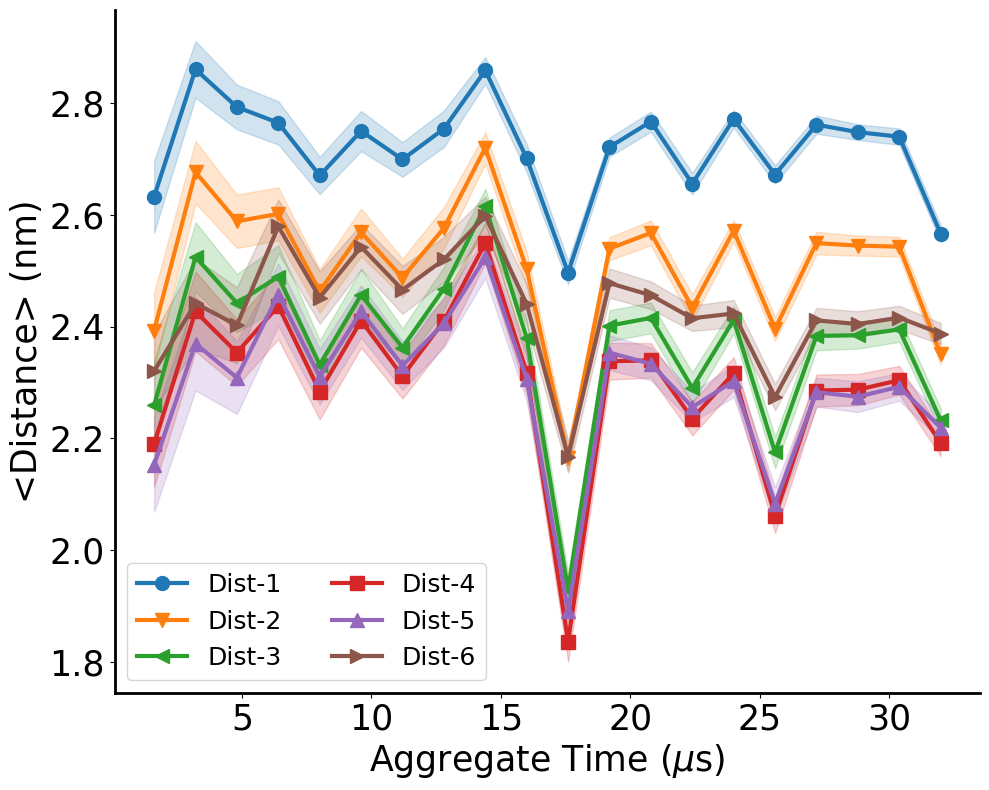

In [35]:
marker=['o','v','<', 's','^','>']

fig, ax = plt.subplots(figsize=(10,8))  # Create a figure and an axes

for d in range(0,6):
    # plt.errorbar(np.arange(0.1,1.1,0.1)*16, mean_dist[d].T[0], yerr=mean_dist[d].T[1], fmt='o', color=plt.cm.tab10(d), markersize=10, capsize=5, capthick=2, label=f'Dist-{d+1}')
    ax.plot(np.arange(0.1,2.1,0.1)*16, mean_dist[d].T[0], color=plt.cm.tab10(d), linewidth=3, label=f'Dist-{d+1}', marker=marker[d], markersize=10)
    ax.fill_between(np.arange(0.1,2.1,0.1)*16, mean_dist[d].T[0]-mean_dist[d].T[1], mean_dist[d].T[0]+mean_dist[d].T[1], color=plt.cm.tab10(d), alpha=0.2)

ax.tick_params(labelsize=25)
ax.set_xlabel(r'Aggregate Time ($\mu$s)', size=25)
ax.set_ylabel(r'<Distance> (nm)', size=25)
ax.legend(fontsize=18, ncol=2)

ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()

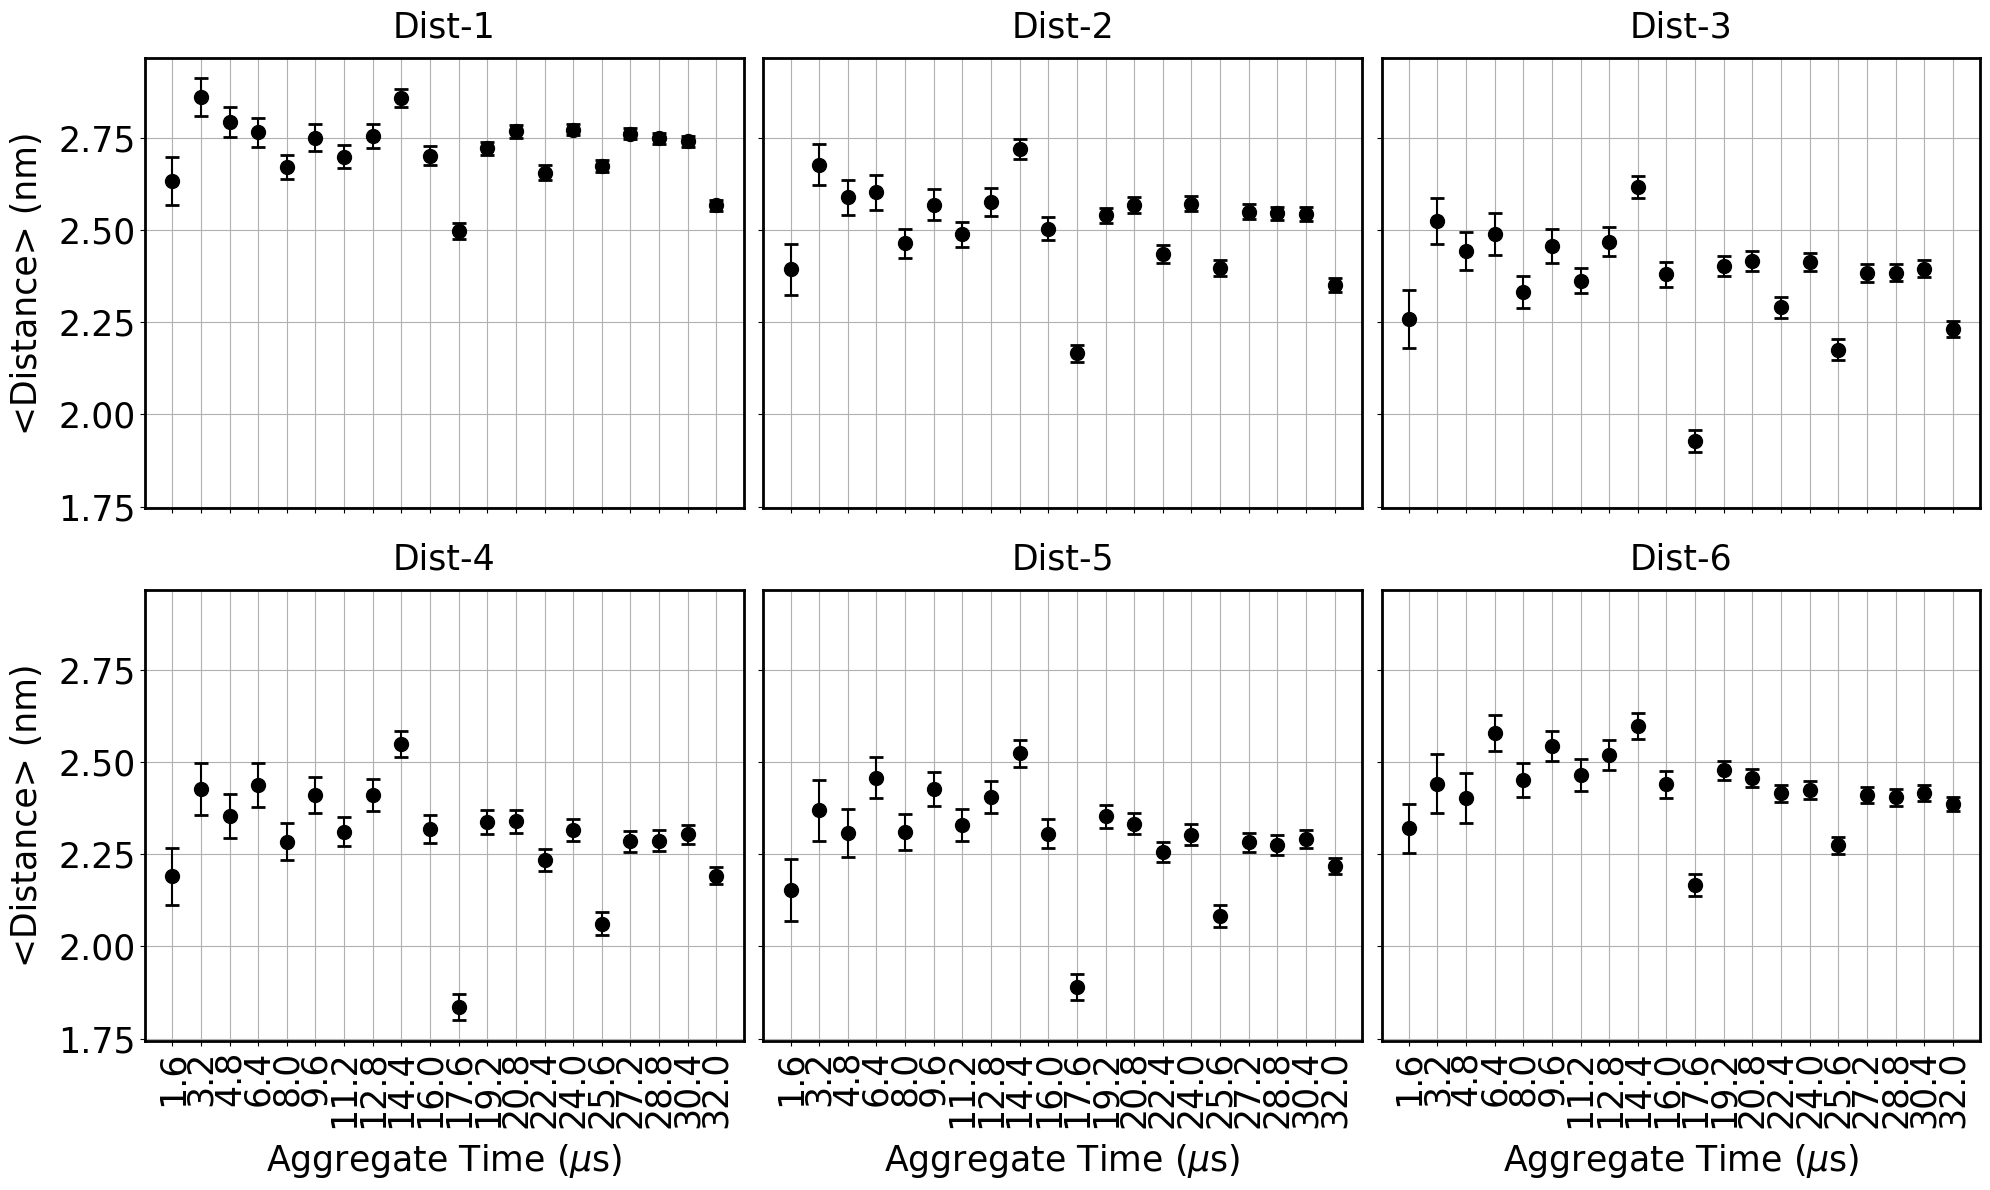

In [38]:
fig, ax = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)

for d in range(0,6):

    p,q = np.unravel_index(d,(2,3))

    ax[p,q].errorbar(np.arange(0.1,2.1,0.1)*16, mean_dist[d].T[0], yerr=mean_dist[d].T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)


    ax[p,q].tick_params(labelsize=25)
    # ax[p,q].set_ylim(-0.2, 2)
    # ax[p,q].set_xlim(0.5, 2.25)
    if p==1 : ax[p,q].set_xlabel(r'Aggregate Time ($\mu$s)', size=25, labelpad=10)
    if q==0 :ax[p,q].set_ylabel(r'<Distance> (nm)', size=25, labelpad=10)

    ax[p,q].set_title(f'Dist-{d+1}', size=25, pad=15)
    ax[p,q].grid()
    ax[p,q].spines['right'].set_linewidth(2)
    ax[p,q].spines['left'].set_linewidth(2)
    ax[p,q].spines['top'].set_linewidth(2)
    ax[p,q].spines['bottom'].set_linewidth(2)

    ax[p,q].set_xticks(np.arange(0.1,2.1,0.1)*16,[round(i,1) for i in np.arange(0.1,2.1,0.1)*16],rotation=90)


plt.tight_layout()


In [4]:
sequence=  ['ASP121', 'ASN122', 'GLU123', 'ALA124', 'TYR125', 'GLU126', 'MET127', 'PRO128', 'SER129', 'GLU130', 'GLU131', 'GLY132', 'TYR133', 'GLN134', 'ASP135',
'TYR136', 'GLU137', 'PRO138', 'GLU139', 'ALA140']

ticks_pnum , ticks_pname = sequence_ticks_1(sequence)


In [5]:
file_name = 'l_contact_map_re.json'

lcm_fas_1 = []
# lcm_fas_2 = []
# lcm_lig47_1 = []
# lcm_lig47_2 = []

for i in range(0, 2000, 100):
    lcm_fas_1.append(load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}'))
    # lcm_fas_2.append(load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}'))
    # lcm_lig47_1.append(load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}'))
    # lcm_lig47_2.append(load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}'))

lcm_fas_1 = np.array([lcm_fas_1[i]['0'] for i in range(len(lcm_fas_1))])
lcm_fas_1 = reposition_first(lcm_fas_1)

# lcm_fas_2 = np.array([lcm_fas_2[i]['0'] for i in range(len(lcm_fas_2))])
# lcm_fas_2 = reposition_first(lcm_fas_2)

# lcm_lig47_1 = np.array([lcm_lig47_1[i]['0'] for i in range(len(lcm_lig47_1))])
# lcm_lig47_1 = reposition_first(lcm_lig47_1)

# lcm_lig47_2 = np.array([lcm_lig47_2[i]['0'] for i in range(len(lcm_lig47_2))])
# lcm_lig47_2 = reposition_first(lcm_lig47_2)

Text(0.5, 0.93, '$\\alpha$-synuclein C-term :Fasudil')

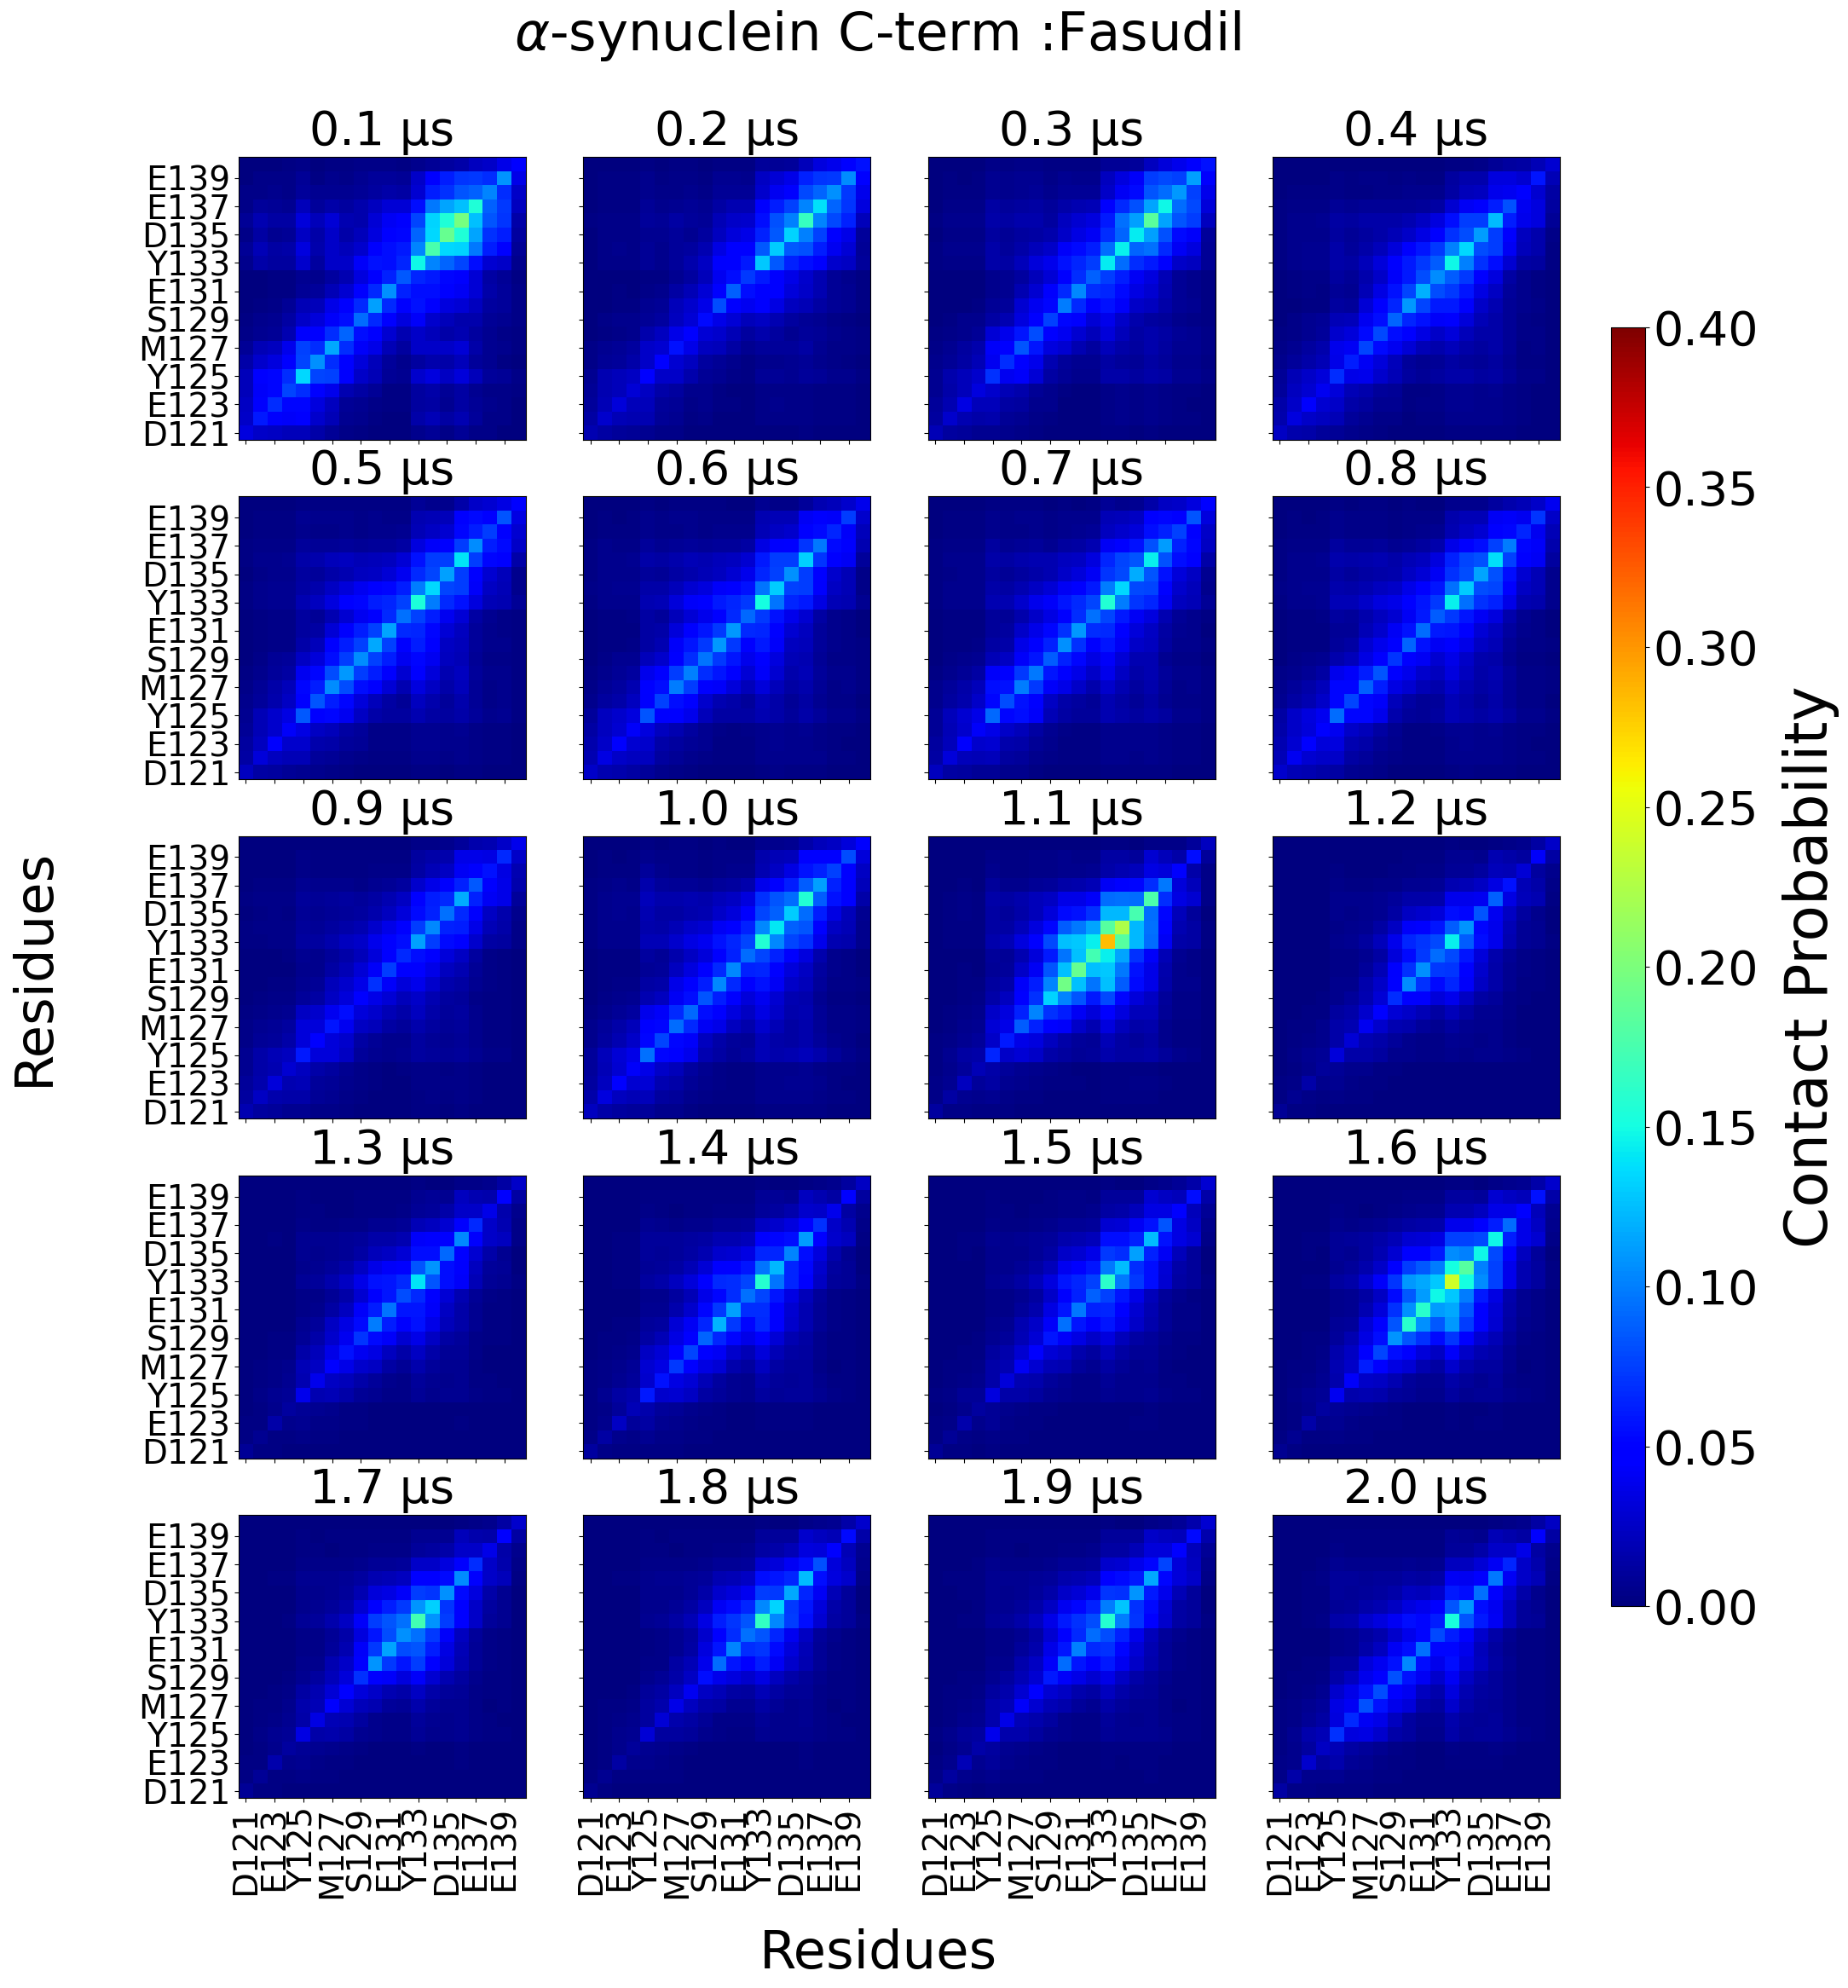

In [10]:
# from mpl_toolkits.axes_grid1 import AxesGrid

fig, axes = plt.subplots(5,4, figsize=(20,25), sharex=True, sharey=True)
cax= fig.add_axes([0.93, 0.2, 0.02, 0.6])
     

images=[]
for i in range(0, 20):
    # ax.set_axis_off()

    contact_map = np.array(lcm_fas_1[i])

    
    p,q = np.unravel_index(i,(5,4))

    im = axes[p,q].imshow(contact_map, vmin=0, vmax=0.4,cmap='jet', aspect='auto')
    axes[p,q].invert_yaxis()
    axes[p,q].set_xticks(range(0, 20,2), ticks_pnum[::2], rotation=90, size=28)
    axes[p,q].set_yticks(range(0, 20,2), ticks_pnum[::2], rotation=0, size=28)
    axes[p,q].grid(False)
    axes[p,q].set_title(f'{((i*100)+100)/1000} \u03bcs',size=40, pad=10)

    # if not q : axes[p,q].set_ylabel("Residues", size=45, labelpad=15)
    # if p == 2-1 : axes[p,q].set_xlabel('Residues', size=45, labelpad=15)
    images.append(im)

for ax in axes.flat :

    if not bool(ax.has_data()):

        fig.delaxes(ax)

# cbar = fig.colorbar(images[-1],cax=cax, orientation="horizontal")
cbar = fig.colorbar(images[-1],cax=cax)

cbar.set_label("Contact Probability", size=50, labelpad=20)
cbar.ax.tick_params(labelsize=40)
# cbar.set_ticks([])
# cbar.set_ticklabels([])

fig.text(0.5, 0.03, "Residues", ha="center", fontsize=45)
fig.text(-0.01, 0.5, "Residues", va="center", rotation="vertical", fontsize=45)

# plt.suptitle("Protein:protien contact matix",size=50 )
fig.text(0.5, 0.93, r'$\alpha$-synuclein C-term :Fasudil', ha="center", fontsize=45)

# plt.grid(alpha=0.1)
# plt.tight_layout()
# plt.savefig(f"{out_dir}/p_cm.png", dpi=1000, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.pdf", dpi=1200, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.eps", dpi=1200, bbox_inches='tight')

# plt.show()
# plt.clf()


In [11]:
cm={}
file_name = 'contact_matrix.json'

for i in range(0,2000, 100):

    if i==0:
        cm[i+2000]=load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}')
    else:
        cm[i]=load_json(f'{work_directory}/{a[1]}/out_{i}/{file_name}')

        

Text(0.5, 0.93, '$\\alpha$-synuclein C-term :Fasudil')

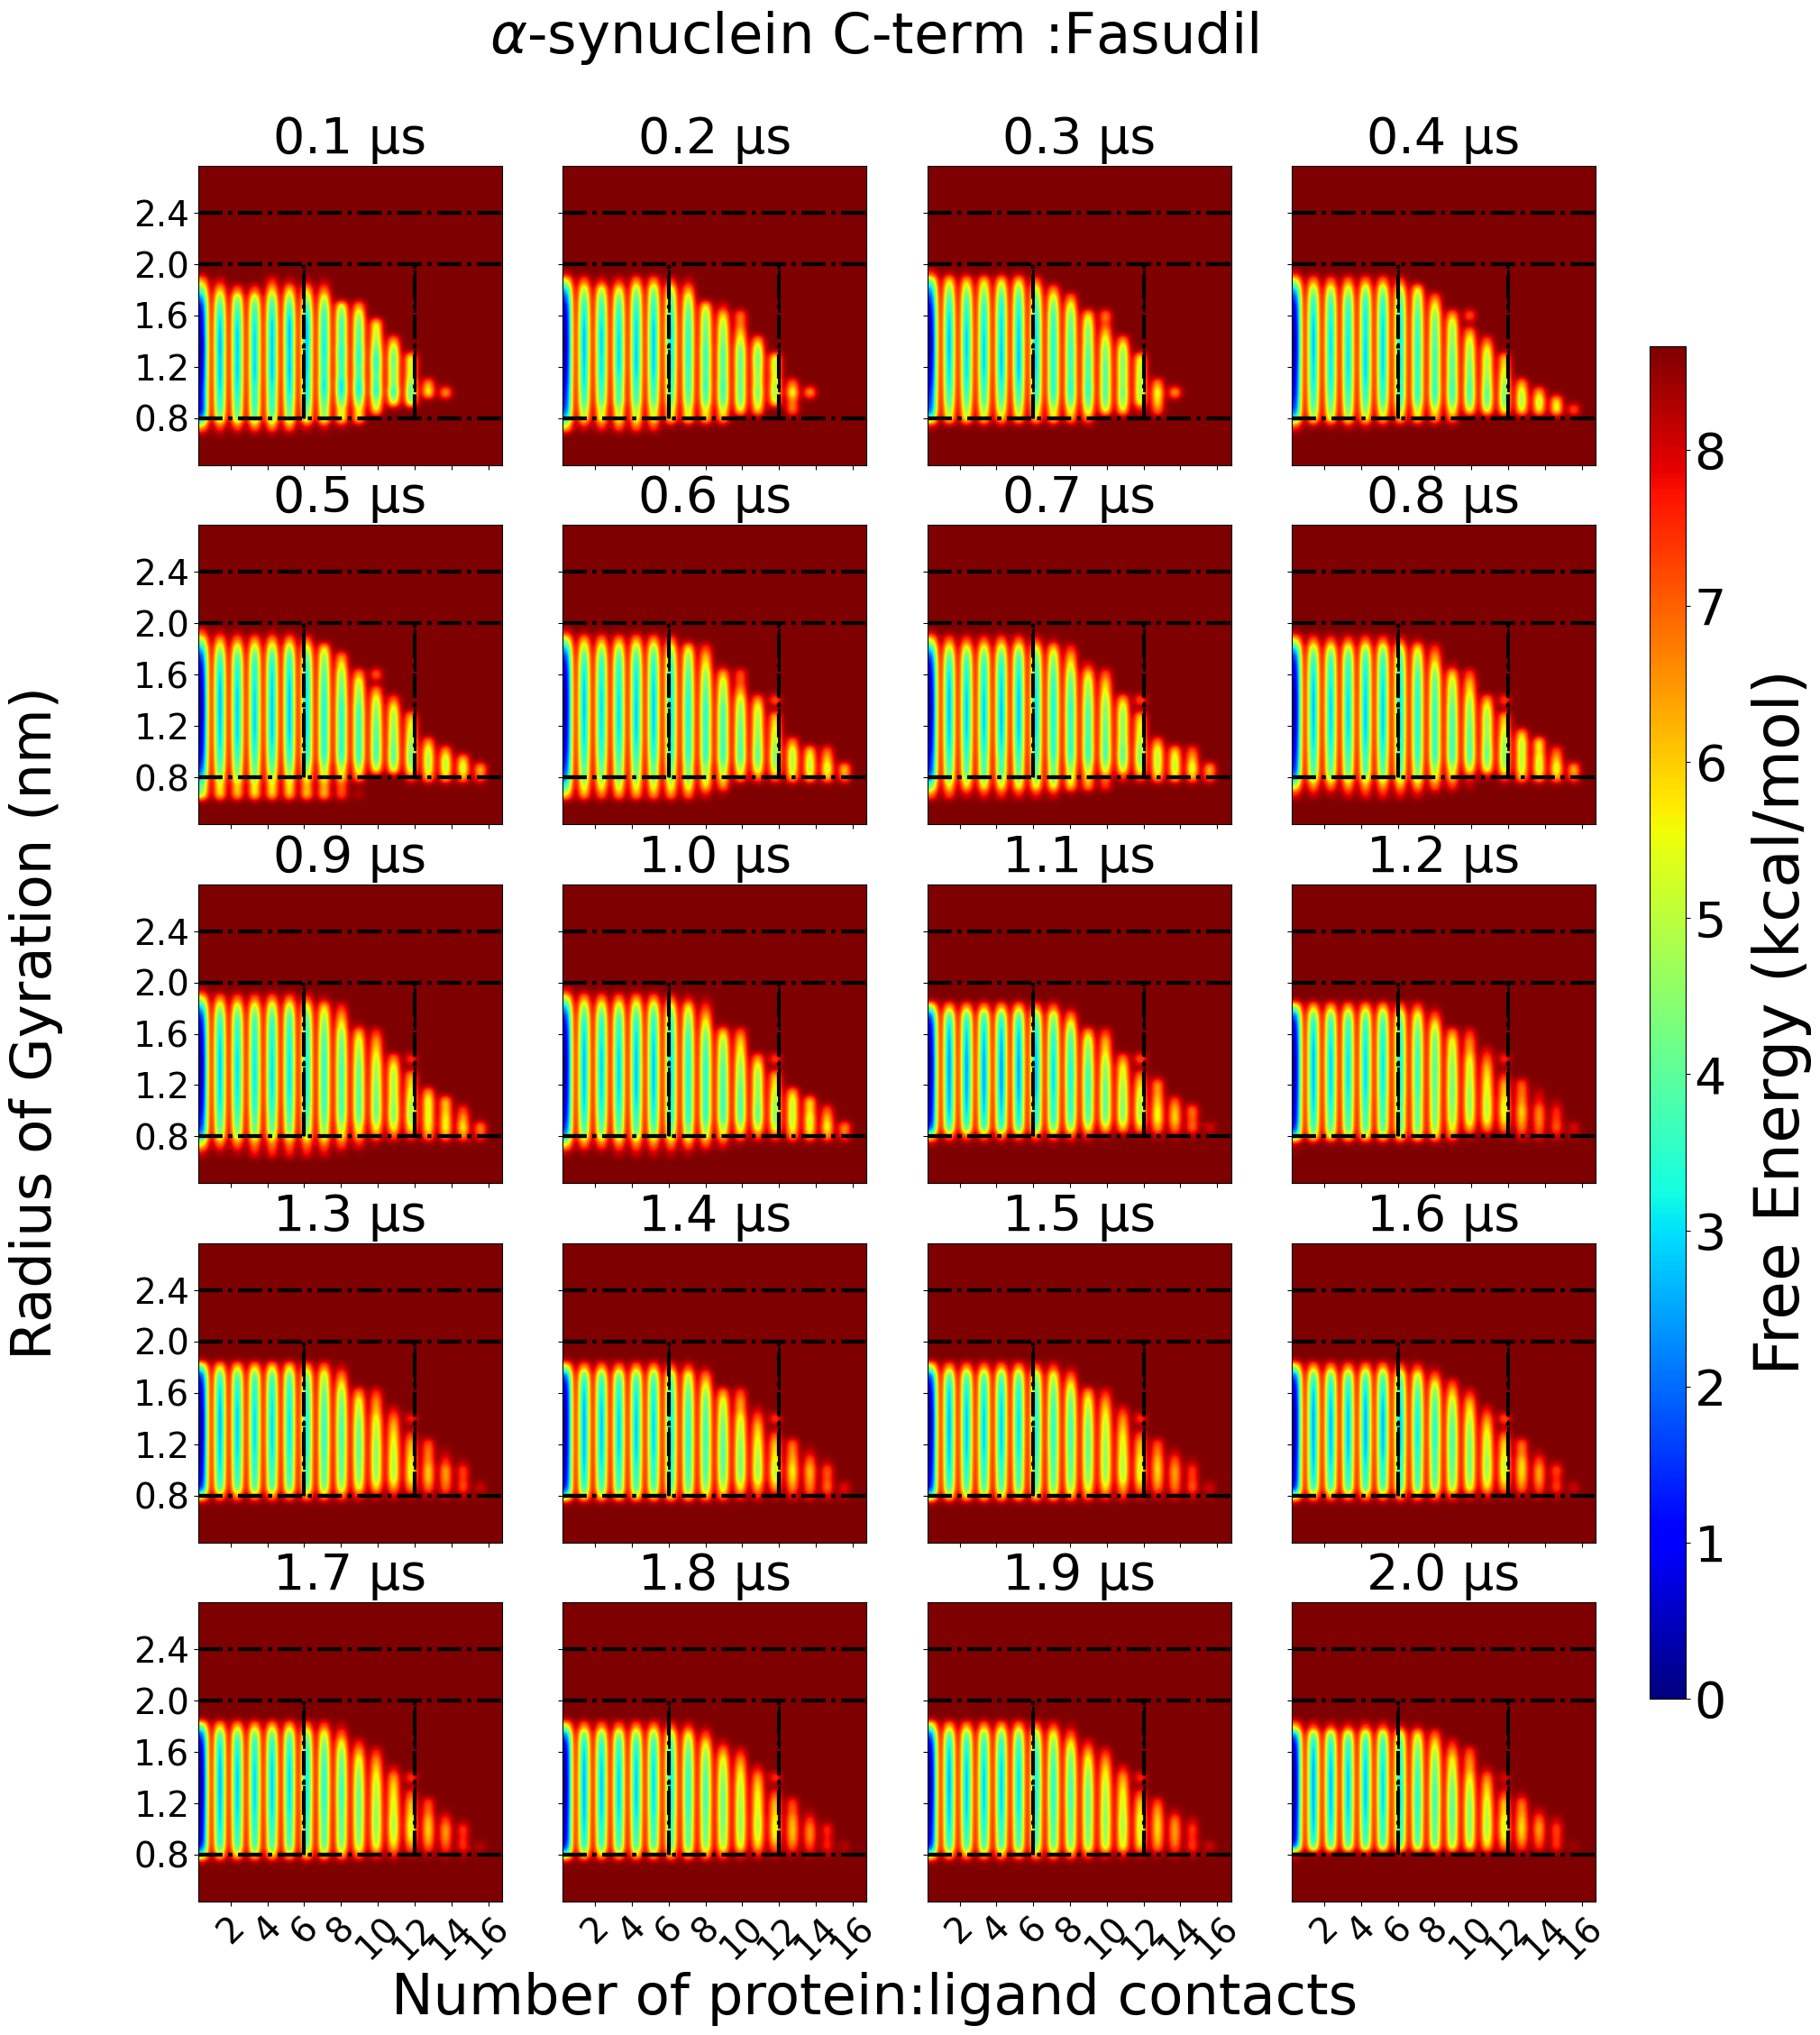

In [14]:
# from mpl_toolkits.axes_grid1 import AxesGrid

histogram_data={}

fig, axes = plt.subplots(5,4, figsize=(20,25), sharex=True, sharey=True)
cax= fig.add_axes([0.93, 0.2, 0.02, 0.6])
     

images=[]
for i in range(100, 2100, 100):
    # ax.set_axis_off()

    fe, xedges,yedges, histogram_data[i]  = free_energy_2D(Y=colvar_data[i].T[index_dict['Rg']], X=np.sum(cm[i]['0'], axis=1),
                                                           T=300,bins=35,
                                                           y0=0.4, ymax=2.8, 
                                                           x0=0, xmax=17,
                                                           weights=weights_norm[i])

    
    p,q = np.unravel_index(int(i/100)-1,(5,4))

    im = axes[p,q].imshow(fe, cmap='jet', aspect='auto',
                          extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                          interpolation='gaussian')
    
    # axes[p,q].invert_yaxis()
    axes[p,q].set_xticks(np.arange(0, 17, 2), np.arange(0, 17, 2), rotation=45, size=28)
    axes[p,q].set_yticks(np.arange(0.4, 3.0, 0.4), [round(i, 1) for i in np.arange(0.4, 3.0, 0.4)], rotation=0, size=28)
    axes[p,q].grid(False)
    axes[p,q].set_title(f'{i/1000} \u03bcs',size=40, pad=10)

    # if not q : axes[p,q].set_ylabel("Residues", size=45, labelpad=15)
    # if p == 2-1 : axes[p,q].set_xlabel('Residues', size=45, labelpad=15)
    images.append(im)

for ax in axes.flat :

    if not bool(ax.has_data()):

        fig.delaxes(ax)

for ax in axes.flat :
        
    ax.axhline(y=0.8, color='black', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='black', lw=3, ls='-.')
    ax.axhline(y=2.0, color='black', lw=3, ls='-.')
    ax.axhline(y=2.4, color='black', lw=3, ls='-.')
    ax.vlines([6,12], 0.8, 2.0, color='black', lw=2, ls='-.')

    ax.axhline(y=0.8, color='black', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='black', lw=3, ls='-.')
    ax.axhline(y=2.0, color='black', lw=3, ls='-.')
    ax.axhline(y=2.4, color='black', lw=3, ls='-.')
    ax.vlines([6,12], 0.8, 2.0, color='black', lw=3, ls='-.')

# cbar = fig.colorbar(images[-1],cax=cax, orientation="horizontal")
cbar = fig.colorbar(images[-1],cax=cax)

cbar.set_label("Free Energy (kcal/mol)", size=50, labelpad=20)
cbar.ax.tick_params(labelsize=40)
# cbar.set_ticks([])
# cbar.set_ticklabels([])

fig.text(0.5, 0.06, "Number of protein:ligand contacts", ha="center", fontsize=45)
fig.text(0.02, 0.5, "Radius of Gyration (nm)", va="center", rotation="vertical", fontsize=45)

# plt.suptitle("Protein:protien contact matix",size=50 )
fig.text(0.5, 0.93, r'$\alpha$-synuclein C-term :Fasudil', ha="center", fontsize=45)

# plt.grid(alpha=0.1)
# plt.tight_layout()
# plt.savefig(f"{out_dir}/p_cm.png", dpi=1000, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.pdf", dpi=1200, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.eps", dpi=1200, bbox_inches='tight')




Text(0.5, 0.93, '$\\alpha$-synuclein C-term :Fasudil')

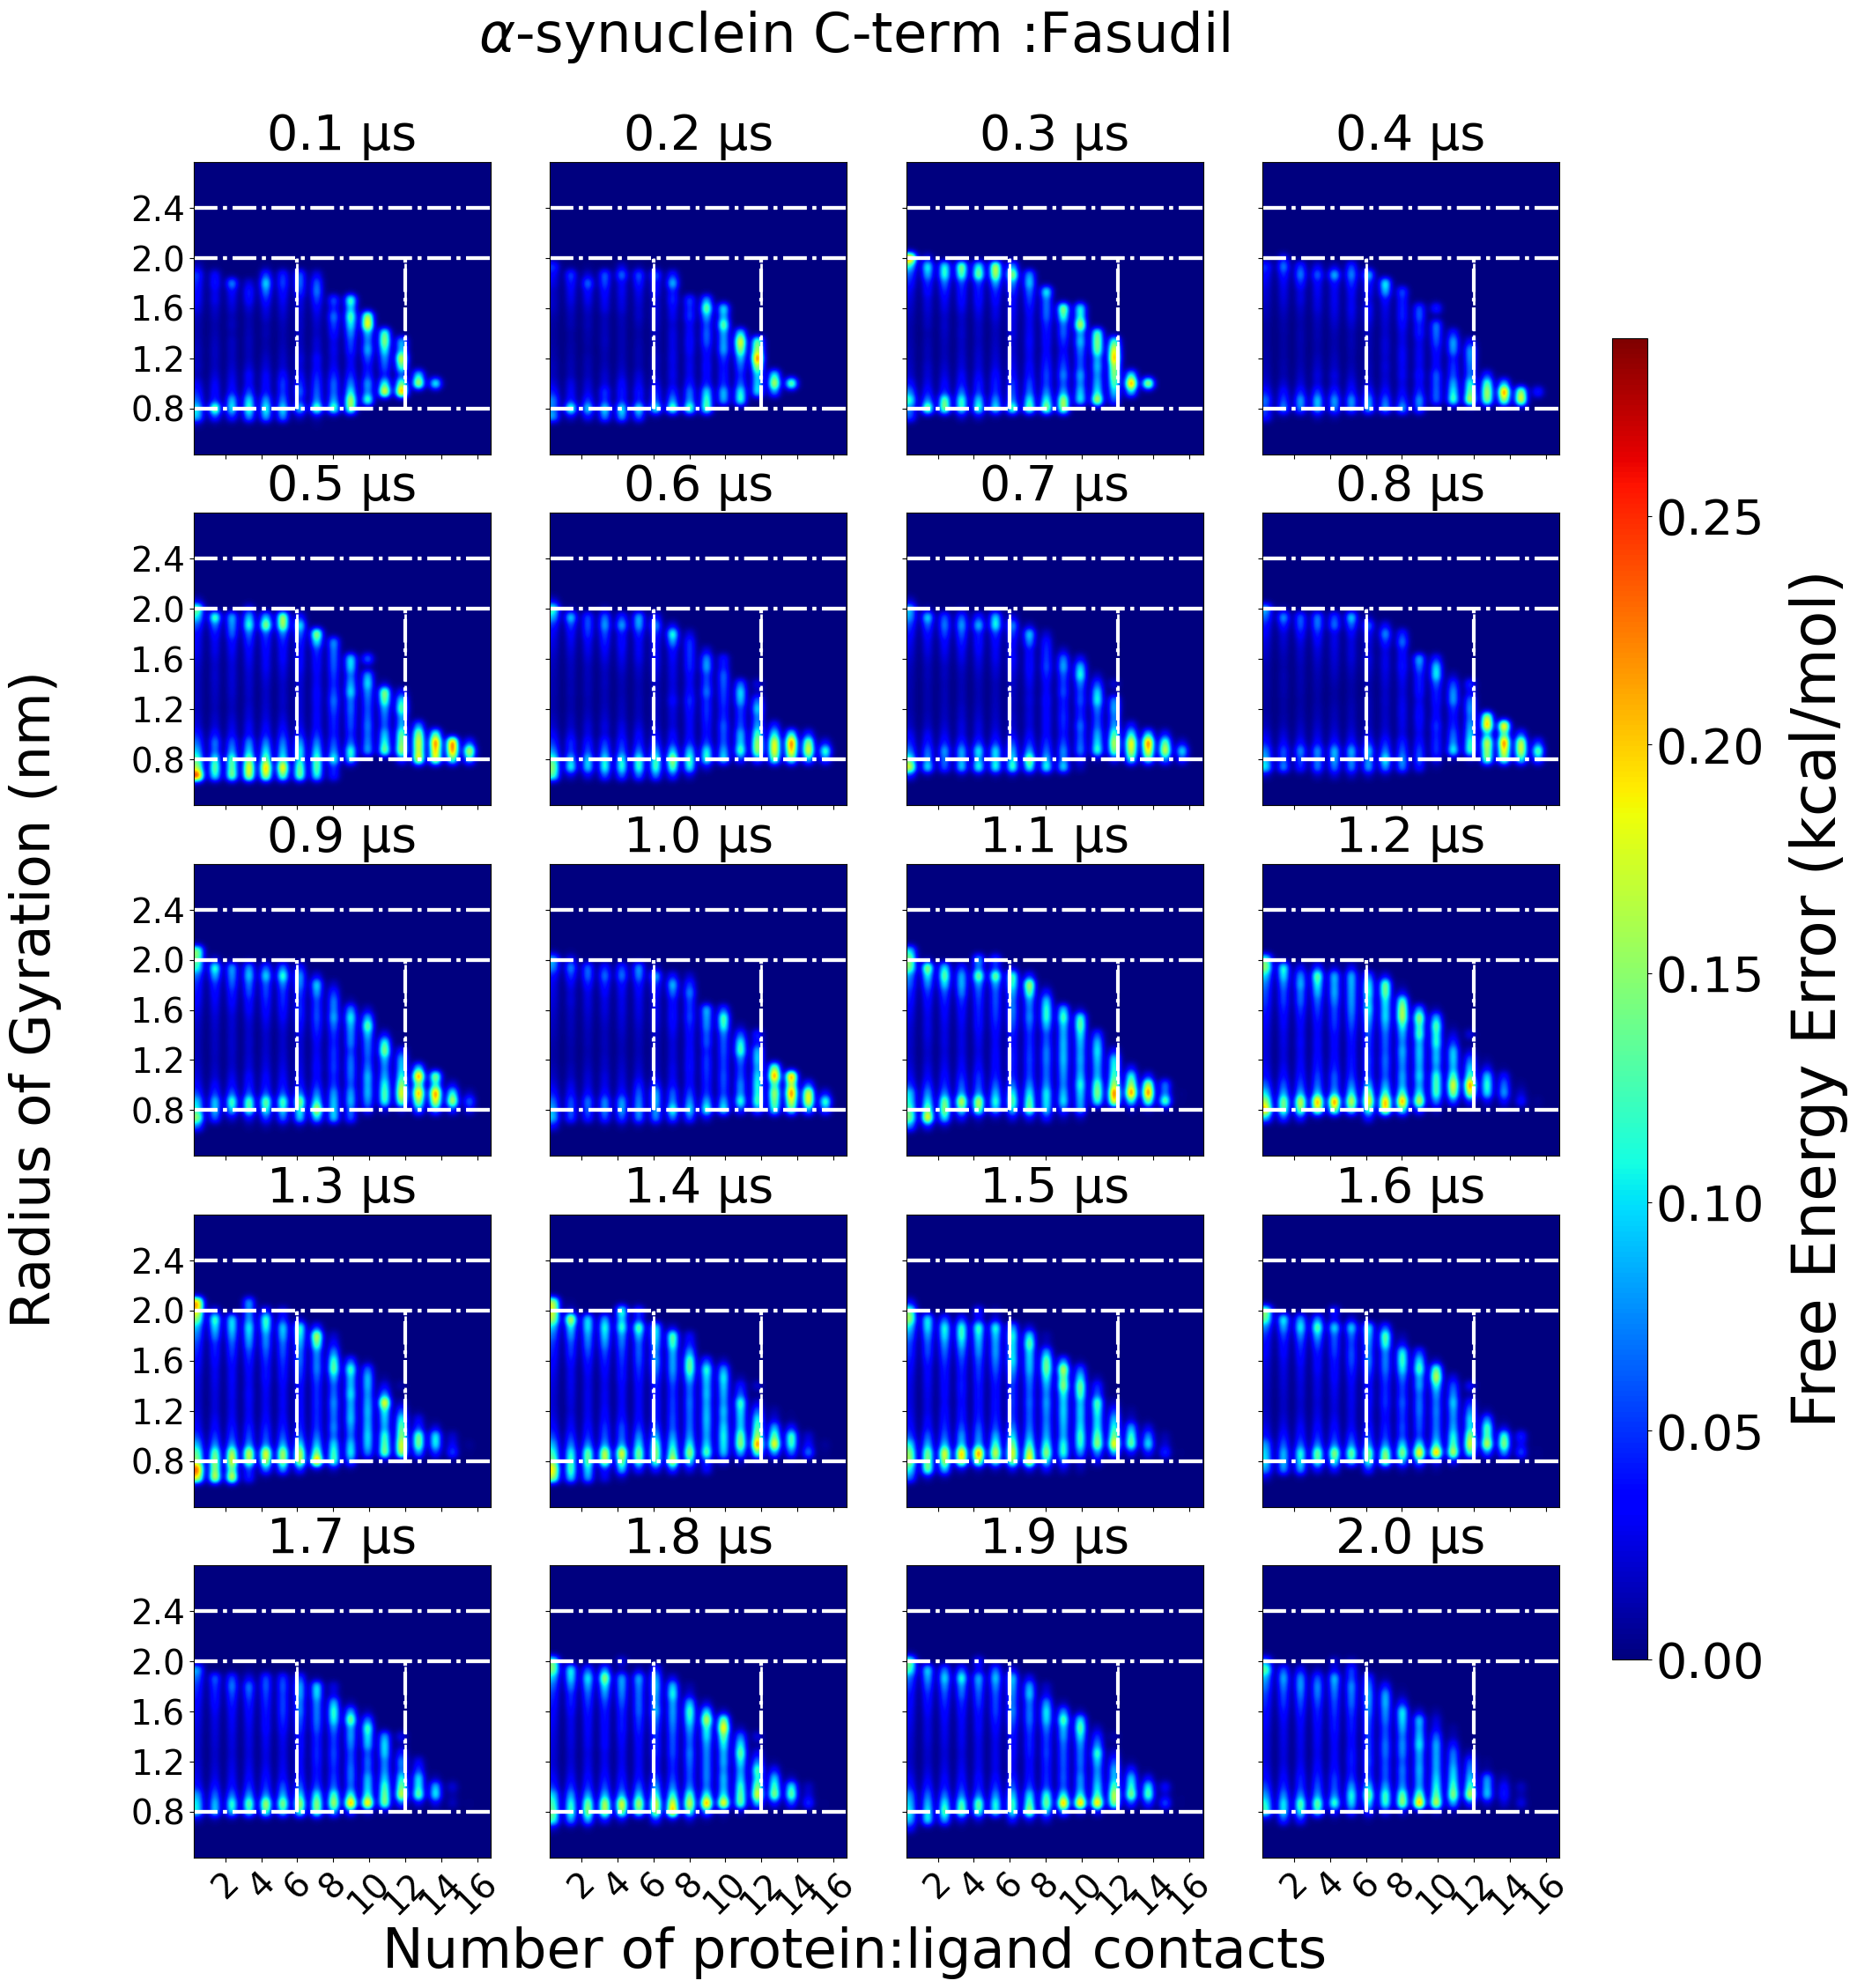

In [58]:
histogram_data={}
mybins=35

fig, axes = plt.subplots(5,4, figsize=(20,25), sharex=True, sharey=True)
cax= fig.add_axes([0.93, 0.2, 0.02, 0.6])
     

images=[]
for i in range(100, 2100, 100):
    # ax.set_axis_off()

    args={'X' : np.sum(cm[i]['0'], axis=1),
        'Y' : colvar_data[i].T[index_dict['Rg']],
        'bin_count' : mybins,
        'y0' : 0.4,
        'ymax' : 2.8,
        'x0' : 0,
        'xmax' : 17,
        'weights': weights_norm[i]}

    bootstrap_results, xcenters, ycenters = blocking_bootstrap_2d_fe(**args) 
    
    p,q = np.unravel_index(int(i/100)-1,(5,4))
    im = axes[p,q].imshow(np.flipud(bootstrap_results.standard_error.reshape(35,35)), cmap='jet', aspect='auto',
                          extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                          interpolation='gaussian')
    
    # axes[p,q].invert_yaxis()
    axes[p,q].set_xticks(np.arange(0, 17, 2), np.arange(0, 17, 2), rotation=45, size=28)
    axes[p,q].set_yticks(np.arange(0.4, 3.0, 0.4), [round(i, 1) for i in np.arange(0.4, 3.0, 0.4)], rotation=0, size=28)
    axes[p,q].grid(False)
    axes[p,q].set_title(f'{i/1000} \u03bcs',size=40, pad=10)

    # if not q : axes[p,q].set_ylabel("Residues", size=45, labelpad=15)
    # if p == 2-1 : axes[p,q].set_xlabel('Residues', size=45, labelpad=15)
    images.append(im)

for ax in axes.flat :

    if not bool(ax.has_data()):

        fig.delaxes(ax)

for ax in axes.flat :
        
    ax.axhline(y=0.8, color='white', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='white', lw=3, ls='-.')
    ax.axhline(y=2.0, color='white', lw=3, ls='-.')
    ax.axhline(y=2.4, color='white', lw=3, ls='-.')
    ax.vlines([6,12], 0.8, 2.0, color='white', lw=2, ls='-.')

    ax.axhline(y=0.8, color='white', lw=3, ls='-.')
    # axes.axhline(y=0.4, color='white', lw=3, ls='-.')
    ax.axhline(y=2.0, color='white', lw=3, ls='-.')
    ax.axhline(y=2.4, color='white', lw=3, ls='-.')
    ax.vlines([6,12], 0.8, 2.0, color='white', lw=3, ls='-.')

# cbar = fig.colorbar(images[-1],cax=cax, orientation="horizontal")
cbar = fig.colorbar(images[-1],cax=cax)

cbar.set_label("Free Energy Error (kcal/mol)", size=50, labelpad=20)
cbar.ax.tick_params(labelsize=40)
# cbar.set_ticks([])
# cbar.set_ticklabels([])

fig.text(0.5, 0.06, "Number of protein:ligand contacts", ha="center", fontsize=45)
fig.text(0.02, 0.5, "Radius of Gyration (nm)", va="center", rotation="vertical", fontsize=45)

# plt.suptitle("Protein:protien contact matix",size=50 )
fig.text(0.5, 0.93, r'$\alpha$-synuclein C-term :Fasudil', ha="center", fontsize=45)

# plt.grid(alpha=0.1)
# plt.tight_layout()
# plt.savefig(f"{out_dir}/p_cm.png", dpi=1000, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.pdf", dpi=1200, bbox_inches='tight')
# plt.savefig(f"{out_dir}/p_cm.eps", dpi=1200, bbox_inches='tight')

# plt.show()
# plt.clf()

# Computing the percentage populations of each quardent

In [60]:
def fe_regions(x, y):
    return np.stack([
        (x >= 0.4) & (x <  0.8) & (y >= 0) & (y <= 18),
        (x >= 0.8) & (x <= 2.0) & (y >= 0) & (y < 6),
        (x >= 0.8) & (x <= 2.0) & (y >= 6) & (y < 12),
        (x >= 0.8) & (x <= 2.0) & (y >= 12) & (y <= 18),
        (x > 2.0) & (x <= 2.4) & (y >= 0) & (y <= 18)
        
    ]).astype(int)

In [62]:
quad_in=[]


for i in range(100, 2100, 100):
    # ax.set_axis_off()


    Y=colvar_data[i].T[index_dict['Rg']]
    X=np.sum(cm[i]['0'], axis=1)

    quad_in.append(fe_regions(x=Y, y=X))


In [89]:
weights_norm_o = OrderedDict(weights_norm)
first_key = next(iter(weights_norm_o))
weights_norm_o.move_to_end(first_key) 
weights_norm_o=dict(weights_norm_o)

In [96]:
q_bootstrap_pyblk=np.zeros((len(quad_in), len(quad_in[0]), 2)) 
la=[]

for i in range(len(quad_in)):

    if i==0 : iw=i+100
    else : iw=(i*100)+100

    la.append(iw)
    
    for j in range(len(quad_in[i])):

                
        q_boot_mean , q_boot_er = get_blockerror_pyblock_nanskip_rw_(np.array(quad_in[i][j]), weights=weights_norm_o[iw])

        q_bootstrap_pyblk[i,j,0] = round(q_boot_mean * 100, 4)  # mean of the bootstrap distribution
        q_bootstrap_pyblk[i,j,1] = q_boot_er * 100   # standard error of the bootstrap distribution
        # q_bootstrap_pyblk[i,j,1] = np.std(np.array(quad_in[i][j]), ddof=1) / np.sqrt(len(np.array(quad_in[i][j])))

In [99]:
import pandas as pd

df = pd.DataFrame(q_bootstrap_pyblk[:, :, 0], columns=['Q1 %', 'Q2 %', 'Q3 %', 'Q4 %', 'Q5 %'])
df.insert(0, 'Simulation', [f"{v/1000} \u03bcs" for v in la])

df.insert(2, 'Q1 err %', [f"{t:5.4f}" for t in q_bootstrap_pyblk.T[1][0]])
df.insert(4, 'Q2 err %', [f"{t:5.4f}" for t in q_bootstrap_pyblk.T[1][1]])
df.insert(6, 'Q3 err %', [f"{t:5.4f}" for t in q_bootstrap_pyblk.T[1][2]])
df.insert(8, 'Q4 err %', [f"{t:5.4f}" for t in q_bootstrap_pyblk.T[1][3]])
df.insert(10, 'Q5 err %', [f"{t:5.4f}" for t in q_bootstrap_pyblk.T[1][4]])

In [100]:
import itables
from itables import init_notebook_mode

itables.show(df, classes="display nowrap cell-border")
